# Project submission

### Group number:
### Student IDs:
### Project name: Cryptocurrency Direction Forecasting and Algorithmic Trading Strategy

## What business problem are you solving?

Crypto assets are highly volatile, and firms involved in crypto trading activity, such as exchanges, brokers, asset managers, or financial services platforms, face the problem of deciding when taking short-term market exposure is justified by the available data.

The business problem we solve is to build a simple algorithmic trading strategy that decides, at the end of each 4-hour candle, whether to take a long position in a cryptocurrency for the next 4-hour candle or stay out of the market. This is relevant because even a small improvement over random directional forecasts can be economically useful when converted into a disciplined and testable trading rule. The difficulty is not only to obtain a model that is accurate, but also to avoid overfitting noisy financial data and to make sure that the model is accurate and not too generalized.

## What is the machine learning problem that you are solving?

The machine learning problem is a binary classification problem. At the end of candle `t`, using only information available up to `t`, we predict whether the next valid 4-hour log return is positive.

The target is:

```python
future_return_4h = log(Close[t+1] / Close[t])
y = 1 if future_return_4h > 0 else 0
```

The output of each model is a probability `P(up)`. We transform this probability into a trading strategy:

```text
if P(up) >= threshold: take a long position for the next 4-hour candle
else: hold no position
```

Therefore the project has two evaluation layers. First, we evaluate the classification model with ROC AUC, precision, recall and F1. Second, we evaluate the trading rule with cumulative return, annualized Sharpe ratio, maximum drawdown and exposure.

## Data exploration and preparation

The EDA notebook showed three important facts. First, the target should be based on returns, not raw future prices, because price levels are highly persistent and would make the task look easier without necessarily producing a useful trading strategy. Second, Maker has large structural gaps and is removed. Third, the other assets have only small residual gaps, so we keep them but prevent returns, targets, lags and rolling features from crossing non-4-hour gaps.

This cell loads the data, checks the structure, removes Maker, creates gap-aware returns and targets, and reports the final modeling sample.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

EXPECTED_FREQ = pd.Timedelta(hours=4)
TRANSACTION_COST = 0.001
CV_TRAIN_ROWS = 25_000

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

In [2]:
def resolve_data_path(filename="pr15_crypto.csv") -> Path:
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        candidate = root / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Unable to locate {filename}")


def load_raw_data():
    data_path = resolve_data_path()
    raw = pd.read_csv(data_path)
    if "Unnamed: 0" in raw.columns:
        raw = raw.drop(columns=["Unnamed: 0"])
    raw["timestamp"] = pd.to_datetime(raw["timestamp"])
    raw = raw.sort_values(["Asset_ID", "timestamp"]).reset_index(drop=True)
    return raw


raw_df = load_raw_data()

print("Raw dataset shape:", raw_df.shape)
display(raw_df.head())
print("Date range:", raw_df["timestamp"].min(), "to", raw_df["timestamp"].max())
print("Assets:", raw_df["Asset_Name"].nunique())
print("Duplicate asset-timestamps:", raw_df.duplicated(["Asset_ID", "timestamp"]).sum())
display(raw_df.isna().sum().to_frame("missing_values"))

Raw dataset shape: (104324, 11)


,Asset_ID,timestamp,Count,Open,High,Low,Close,Volume,VWAP,Weight,Asset_Name
0,0,2018-01-01 00:00:00,3272.0,8.5300,8.5300,8.1305,8.3401,136150.46,8.327702,4.304065,Binance Coin
1,0,2018-01-01 04:00:00,3231.0,8.3612,8.7000,8.3410,8.3600,100304.70,8.485586,4.304065,Binance Coin
2,0,2018-01-01 08:00:00,3412.0,8.3852,8.5300,8.0703,8.1604,113605.91,8.274129,4.304065,Binance Coin
3,0,2018-01-01 12:00:00,3678.0,8.1800,8.3300,7.8000,8.1101,156761.84,8.063121,4.304065,Binance Coin
4,0,2018-01-01 16:00:00,2030.0,8.1160,8.1778,7.9592,8.1150,61915.82,8.063309,4.304065,Binance Coin


Date range: 2018-01-01 00:00:00 to 2021-09-20 20:00:00
Assets: 14
Duplicate asset-timestamps: 0


,missing_values
Asset_ID,0
timestamp,0
Count,0
Open,0
High,0
Low,0
Close,0
Volume,0
VWAP,0
Weight,0


In [3]:
def add_gap_aware_target_and_features(raw):
    df = raw.loc[raw["Asset_Name"] != "Maker"].copy()
    df = df.sort_values(["Asset_ID", "timestamp"]).reset_index(drop=True)

    g_asset = df.groupby("Asset_ID", group_keys=False)
    df["prev_timestamp"] = g_asset["timestamp"].shift(1)
    df["next_timestamp"] = g_asset["timestamp"].shift(-1)
    df["prev_delta"] = df["timestamp"] - df["prev_timestamp"]
    df["next_delta"] = df["next_timestamp"] - df["timestamp"]
    df["valid_prev_4h"] = df["prev_delta"].eq(EXPECTED_FREQ)
    df["valid_next_4h"] = df["next_delta"].eq(EXPECTED_FREQ)

    df["new_segment"] = ~df["valid_prev_4h"]
    df["segment_id"] = df.groupby("Asset_ID")["new_segment"].cumsum().astype(int)

    df["Log_Close"] = np.log(df["Close"])
    df["Log_Return"] = np.where(
        df["valid_prev_4h"],
        df["Log_Close"] - g_asset["Log_Close"].shift(1),
        np.nan,
    )
    df["Future_Log_Return_4H"] = np.where(
        df["valid_next_4h"],
        g_asset["Log_Close"].shift(-1) - df["Log_Close"],
        np.nan,
    )
    df["Target_Up_4H"] = np.where(
        df["Future_Log_Return_4H"].notna(),
        (df["Future_Log_Return_4H"] > 0).astype(int),
        np.nan,
    )

    vwap_finite = np.isfinite(df["VWAP"])
    vwap_inside_range = df["VWAP"].between(df["Low"], df["High"], inclusive="both")
    df["VWAP_Clean"] = df["VWAP"].where(vwap_finite & vwap_inside_range, np.nan)

    df["High_Low_Range"] = (df["High"] - df["Low"]) / df["Open"]
    df["VWAP_Deviation"] = (df["Close"] - df["VWAP_Clean"]) / df["Close"]
    df["Log_Volume"] = np.log1p(df["Volume"])
    df["Log_Count"] = np.log1p(df["Count"])

    g_segment = df.groupby(["Asset_ID", "segment_id"], group_keys=False)
    df["Return_Current_4H"] = df["Log_Return"]
    df["Return_Lag_1"] = g_segment["Log_Return"].shift(1)
    df["Return_Lag_2"] = g_segment["Log_Return"].shift(2)
    df["Return_Lag_3"] = g_segment["Log_Return"].shift(3)
    df["Rolling_Return_Mean_6"] = g_segment["Log_Return"].transform(lambda s: s.rolling(6, min_periods=4).mean())
    df["Rolling_Volatility_6"] = g_segment["Log_Return"].transform(lambda s: s.rolling(6, min_periods=4).std())
    df["Rolling_Volatility_42"] = g_segment["Log_Return"].transform(lambda s: s.rolling(42, min_periods=24).std())
    df["Log_Count_Change_1"] = g_segment["Log_Count"].diff(1)

    return_pivot = df.pivot(index="timestamp", columns="Asset_ID", values="Log_Return")
    market_sum = return_pivot.sum(axis=1, skipna=True)
    market_count = return_pivot.count(axis=1)
    btc_return = return_pivot[1].rename("BTC_Return")
    eth_return = return_pivot[6].rename("ETH_Return")

    df["BTC_Return"] = df["timestamp"].map(btc_return)
    df["ETH_Return"] = df["timestamp"].map(eth_return)
    df["Market_Return_Ex_Asset"] = (df["timestamp"].map(market_sum) - df["Log_Return"]) / (df["timestamp"].map(market_count) - 1)
    return df


model_df = add_gap_aware_target_and_features(raw_df)

numeric_features = [
    "Return_Current_4H", "Return_Lag_1", "Return_Lag_2", "Return_Lag_3",
    "Rolling_Return_Mean_6", "Rolling_Volatility_6", "Rolling_Volatility_42",
    "High_Low_Range", "VWAP_Deviation", "Log_Volume", "Log_Count_Change_1",
    "Market_Return_Ex_Asset", "BTC_Return", "ETH_Return",
]
categorical_features = ["Asset_Name"]
feature_columns = numeric_features + categorical_features
target_col = "Target_Up_4H"
return_col = "Future_Log_Return_4H"

model_df = model_df[model_df[target_col].notna()].copy()
model_df[target_col] = model_df[target_col].astype(int)
model_df = model_df.sort_values("timestamp").reset_index(drop=True)

print("Modeling dataset after excluding Maker and invalid future targets:", model_df.shape)
print("Assets kept:", model_df["Asset_Name"].nunique())
print("Target up-rate:", round(model_df[target_col].mean(), 4))
display(model_df.groupby("Asset_Name").agg(rows=(target_col, "size"), up_rate=(target_col, "mean")).sort_values("rows", ascending=False))
display(model_df[feature_columns + [target_col, return_col]].isna().mean().sort_values(ascending=False).to_frame("missing_share"))

Modeling dataset after excluding Maker and invalid future targets: (101220, 39)
Assets kept: 13
Target up-rate: 0.5043


,rows,up_rate
Asset_Name,,
Bitcoin,8153,0.515638
Bitcoin Cash,8153,0.497976
EOS.IO,8153,0.504477
Ethereum,8153,0.508157
Ethereum Classic,8153,0.498344
Litecoin,8153,0.501288
Monero,8149,0.514419
Binance Coin,8133,0.512480
TRON,7932,0.504917


,missing_share
Rolling_Volatility_42,0.007410
Return_Lag_3,0.001413
Rolling_Return_Mean_6,0.001413
Rolling_Volatility_6,0.001413
Return_Lag_2,0.001067
Return_Lag_1,0.000721
Return_Current_4H,0.000366
Log_Count_Change_1,0.000366
Market_Return_Ex_Asset,0.000366
ETH_Return,0.000079


### Interpretation of the prepared modeling dataset

The raw dataset has 104,324 observations, 11 variables, 14 assets, no missing values and no duplicate asset-timestamps. After removing Maker and invalid future-target rows, the modeling dataset has 101,220 observations and 13 assets. The target up-rate is approximately 50.4%, so the task is nearly balanced and accuracy alone would not be sufficient to judge performance.

The remaining missing values are created by lag and rolling-window construction, not by raw data quality problems. They are handled inside the modeling pipeline with median imputation, which is fit only on training data or training folds.

## Feature engineering

The feature set follows the EDA conclusions and the course methodology on transformations, scaling, pipelines and leakage control. We do not use raw future information and we do not use raw price levels as direct predictors. Instead, every feature is observable at the end of candle `t`.

The features are grouped as follows:

- return dynamics: current return and short lags;
- local momentum/mean reversion: rolling mean of returns;
- risk regime: short and longer rolling volatility;
- candle pressure: high-low range and deviation from VWAP;
- liquidity/activity: log volume and change in log trade count;
- market context: BTC, ETH and equal-weighted market return excluding the asset itself;
- asset identity: one-hot encoded `Asset_Name`.

## Temporal split

Financial observations are time ordered, so we use a chronological split rather than a random split. The validation period is used for model selection and threshold selection. The test period is held out until the final evaluation.

For hyperparameter tuning, we use `TimeSeriesSplit` only within the training period. To keep the notebook executable, the grid search uses the most recent part of the training period and then refits the selected hyperparameters on the full training set.

In [4]:
train_end = pd.Timestamp("2020-12-31 23:59:59")
validation_end = pd.Timestamp("2021-05-31 23:59:59")

train_df = model_df[model_df["timestamp"] <= train_end].copy()
validation_df = model_df[(model_df["timestamp"] > train_end) & (model_df["timestamp"] <= validation_end)].copy()
test_df = model_df[model_df["timestamp"] > validation_end].copy()

X_train = train_df[feature_columns]
y_train = train_df[target_col]
X_validation = validation_df[feature_columns]
y_validation = validation_df[target_col]
X_test = test_df[feature_columns]
y_test = test_df[target_col]

train_tuning_df = train_df.tail(min(CV_TRAIN_ROWS, len(train_df))).copy()
X_train_tuning = train_tuning_df[feature_columns]
y_train_tuning = train_tuning_df[target_col]

split_summary = []
for split_name, part in [("train", train_df), ("validation", validation_df), ("test", test_df), ("train_tuning", train_tuning_df)]:
    split_summary.append({
        "split": split_name,
        "rows": len(part),
        "start": part["timestamp"].min(),
        "end": part["timestamp"].max(),
        "up_rate": part[target_col].mean(),
    })

display(pd.DataFrame(split_summary))

,split,rows,start,end,up_rate
0,train,80719,2018-01-01 00:00:00,2020-12-31 20:00:00,0.500564
1,validation,11778,2021-01-01 00:00:00,2021-05-31 20:00:00,0.535150
2,test,8723,2021-06-01 00:00:00,2021-09-20 16:00:00,0.497535
3,train_tuning,25000,2020-02-15 08:00:00,2020-12-31 20:00:00,0.516640


## Modeling

Following the course notebooks, all preprocessing is inside a scikit-learn `Pipeline`. Numeric variables are median-imputed and standardized. The categorical asset name is imputed and one-hot encoded. This prevents data leakage because the imputer, scaler and encoder are fit only on the training fold during cross-validation.

We compare the six models discussed for the project:

1. Logistic Regression;
2. KNN;
3. Decision Tree;
4. Random Forest;
5. Gradient Boosting;
6. Neural Network.

The first five are tuned together as classical models. The neural network is trained separately, as requested in the assignment.

In [5]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


def get_positive_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return 1 / (1 + np.exp(-scores))


def classification_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "average_precision": average_precision_score(y_true, y_proba),
    }


def evaluate_classifier(model, X, y, threshold=0.50):
    y_proba = get_positive_proba(model, X)
    y_pred = (y_proba >= threshold).astype(int)
    return classification_metrics(y, y_pred, y_proba)


def trading_metrics(evaluation_df, proba, threshold=0.50, transaction_cost=TRANSACTION_COST):
    temp = evaluation_df[["timestamp", "Asset_ID", return_col]].copy()
    temp["proba_up"] = proba
    temp["position"] = (temp["proba_up"] >= threshold).astype(int)
    temp = temp.sort_values(["Asset_ID", "timestamp"])
    temp["trade"] = temp.groupby("Asset_ID")["position"].diff().abs().fillna(temp["position"])
    temp["strategy_return"] = temp["position"] * temp[return_col] - transaction_cost * temp["trade"]

    period_returns = temp.groupby("timestamp")["strategy_return"].mean().sort_index()
    cumulative_return = np.exp(period_returns.sum()) - 1
    periods_per_year = 6 * 365
    sharpe = np.sqrt(periods_per_year) * period_returns.mean() / period_returns.std() if period_returns.std() > 0 else np.nan
    equity_curve = np.exp(period_returns.cumsum())
    max_drawdown = (equity_curve / equity_curve.cummax() - 1).min()

    return {
        "threshold": threshold,
        "cumulative_return": cumulative_return,
        "annualized_sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "avg_position_rate": temp["position"].mean(),
        "turnover": temp["trade"].mean(),
        "n_trades": int(temp["trade"].sum()),
    }


def buy_and_hold_metrics(evaluation_df):
    period_returns = evaluation_df.groupby("timestamp")[return_col].mean().sort_index()
    cumulative_return = np.exp(period_returns.sum()) - 1
    periods_per_year = 6 * 365
    sharpe = np.sqrt(periods_per_year) * period_returns.mean() / period_returns.std() if period_returns.std() > 0 else np.nan
    equity_curve = np.exp(period_returns.cumsum())
    max_drawdown = (equity_curve / equity_curve.cummax() - 1).min()
    return {
        "cumulative_return": cumulative_return,
        "annualized_sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "avg_position_rate": 1.0,
        "turnover": 0.0,
        "n_trades": 0,
    }


def select_threshold_on_validation(model, X_val, y_val, validation_frame, thresholds=np.arange(0.50, 0.651, 0.01)):
    proba = get_positive_proba(model, X_val)
    rows = []
    for threshold in thresholds:
        y_pred = (proba >= threshold).astype(int)
        cls = classification_metrics(y_val, y_pred, proba)
        trd = trading_metrics(validation_frame, proba, threshold=threshold)
        rows.append({"threshold": threshold, **cls, **trd})
    results = pd.DataFrame(rows)
    feasible = results[results["avg_position_rate"] >= 0.05]
    if feasible.empty:
        feasible = results
    best = feasible.sort_values(["annualized_sharpe", "roc_auc"], ascending=False).iloc[0]
    return float(best["threshold"]), results

### Baseline models

Before fitting complex models, we need baselines. The majority-class baseline checks whether accuracy is misleading in a nearly balanced target. The stratified baseline represents random class predictions with the same class distribution as the training data.

In [6]:
baseline_rows = []
for strategy in ["most_frequent", "stratified"]:
    baseline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("classifier", DummyClassifier(strategy=strategy, random_state=SEED)),
    ])
    baseline.fit(X_train, y_train)
    metrics = evaluate_classifier(baseline, X_validation, y_validation)
    baseline_rows.append({"model": f"DummyClassifier({strategy})", **metrics})

baseline_results_df = pd.DataFrame(baseline_rows)
display(baseline_results_df)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,DummyClassifier(most_frequent),0.535150,0.500000,0.535150,1.000000,0.697196,0.500000,0.535150
1,DummyClassifier(stratified),0.497877,0.497399,0.532596,0.504204,0.518011,0.497399,0.533862


### Classical models with time-aware hyperparameter tuning

Each model is tuned with at least two hyperparameters, following the grid-search approach used in the class notebooks. We optimize ROC AUC because it evaluates the ranking quality of predicted probabilities independently of a fixed threshold. This is appropriate because the final trading threshold is selected after probability estimation.

In [7]:
tscv = TimeSeriesSplit(n_splits=3)

model_specs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000, solver="lbfgs", random_state=SEED),
        "param_grid": {
            "classifier__C": [0.1, 1.0, 10.0],
            "classifier__class_weight": [None, "balanced"],
        },
    },
    "KNN": {
        "estimator": KNeighborsClassifier(n_jobs=-1),
        "param_grid": {
            "classifier__n_neighbors": [25, 75],
            "classifier__weights": ["uniform", "distance"],
        },
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=SEED),
        "param_grid": {
            "classifier__max_depth": [3, 6, 10],
            "classifier__min_samples_leaf": [100, 500],
        },
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(n_estimators=80, n_jobs=-1, random_state=SEED),
        "param_grid": {
            "classifier__max_depth": [4, 8],
            "classifier__min_samples_leaf": [100, 500],
            "classifier__max_features": ["sqrt", 0.5],
        },
    },
    "Gradient Boosting": {
        "estimator": HistGradientBoostingClassifier(random_state=SEED),
        "param_grid": {
            "classifier__learning_rate": [0.03, 0.10],
            "classifier__max_leaf_nodes": [15, 31],
            "classifier__l2_regularization": [0.0, 0.1],
        },
    },
}

search_rows = []
best_models = {}
threshold_tables = {}

for model_name, spec in model_specs.items():
    print(f"\n--- Tuning {model_name} ---")
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("classifier", spec["estimator"]),
    ])
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=spec["param_grid"],
        scoring="roc_auc",
        cv=tscv,
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_train_tuning, y_train_tuning)

    best_model = clone(grid.best_estimator_)
    best_model.fit(X_train, y_train)
    best_models[model_name] = best_model

    validation_metrics = evaluate_classifier(best_model, X_validation, y_validation)
    best_threshold, threshold_table = select_threshold_on_validation(best_model, X_validation, y_validation, validation_df)
    threshold_tables[model_name] = threshold_table

    search_rows.append({
        "model": model_name,
        "best_cv_roc_auc": grid.best_score_,
        "validation_threshold": best_threshold,
        **validation_metrics,
        "best_params": grid.best_params_,
    })

    print("Best CV ROC AUC:", round(grid.best_score_, 4))
    print("Best params:", grid.best_params_)
    print("Validation ROC AUC:", round(validation_metrics["roc_auc"], 4), "| F1@0.50:", round(validation_metrics["f1"], 4), "| threshold:", round(best_threshold, 2))

classical_results_df = pd.DataFrame(search_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(classical_results_df.drop(columns="best_params"))
display(classical_results_df[["model", "best_params"]])


--- Tuning Logistic Regression ---


Best CV ROC AUC: 0.5708
Best params: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}
Validation ROC AUC: 0.5609 | F1@0.50: 0.5905 | threshold: 0.53

--- Tuning KNN ---


Best CV ROC AUC: 0.5454
Best params: {'classifier__n_neighbors': 75, 'classifier__weights': 'distance'}
Validation ROC AUC: 0.5394 | F1@0.50: 0.5279 | threshold: 0.63

--- Tuning Decision Tree ---


Best CV ROC AUC: 0.5422
Best params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 100}
Validation ROC AUC: 0.5283 | F1@0.50: 0.522 | threshold: 0.64

--- Tuning Random Forest ---


Best CV ROC AUC: 0.5638
Best params: {'classifier__max_depth': 4, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 100}
Validation ROC AUC: 0.5628 | F1@0.50: 0.5506 | threshold: 0.52

--- Tuning Gradient Boosting ---


Best CV ROC AUC: 0.5546
Best params: {'classifier__l2_regularization': 0.1, 'classifier__learning_rate': 0.03, 'classifier__max_leaf_nodes': 15}
Validation ROC AUC: 0.548 | F1@0.50: 0.5445 | threshold: 0.5


,model,best_cv_roc_auc,validation_threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Random Forest,0.563817,0.52,0.550178,0.552851,0.591613,0.514834,0.550560,0.562827,0.590126
1,Logistic Regression,0.570784,0.53,0.551367,0.547363,0.577209,0.604315,0.590451,0.560868,0.578994
2,Gradient Boosting,0.554596,0.50,0.540160,0.542171,0.579381,0.513565,0.544491,0.548000,0.574198
3,KNN,0.545386,0.63,0.525981,0.528299,0.565170,0.495320,0.527945,0.539393,0.576761
4,Decision Tree,0.542227,0.64,0.519528,0.521742,0.558165,0.490243,0.522004,0.528328,0.556637


,model,best_params
0,Random Forest,"{'classifier__max_depth': 4, 'classifier__max_..."
1,Logistic Regression,"{'classifier__C': 0.1, 'classifier__class_weig..."
2,Gradient Boosting,"{'classifier__l2_regularization': 0.1, 'classi..."
3,KNN,"{'classifier__n_neighbors': 75, 'classifier__w..."
4,Decision Tree,"{'classifier__max_depth': 10, 'classifier__min..."


### Interpretation of the classical model comparison

All classical models perform only modestly above random, which is a sensible result for high-frequency financial direction prediction. Random Forest and Logistic Regression are the strongest validation models. Logistic Regression being competitive suggests that part of the signal is approximately linear, while Random Forest slightly improves validation ROC AUC by allowing non-linear interactions between return, volatility, liquidity and market-context features.

KNN and Decision Tree are weaker. KNN suffers because similar historical observations do not necessarily imply similar future returns in noisy markets. A single Decision Tree is interpretable but unstable. The ensemble models reduce this instability, which is why Random Forest and Gradient Boosting are more appropriate candidates.

### Neural network

The neural network is trained separately. In the course notebooks this is done with Keras/TensorFlow; in this local environment TensorFlow is not installed, so we use scikit-learn's `MLPClassifier`, which is still a fully connected feed-forward neural network. We keep the same methodology: scaled inputs, early stopping, validation monitoring and hyperparameter tuning.

Best CV ROC AUC: 0.5607
Best params: {'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (32,), 'classifier__learning_rate_init': 0.001}
Validation ROC AUC: 0.5496
Selected threshold: 0.65


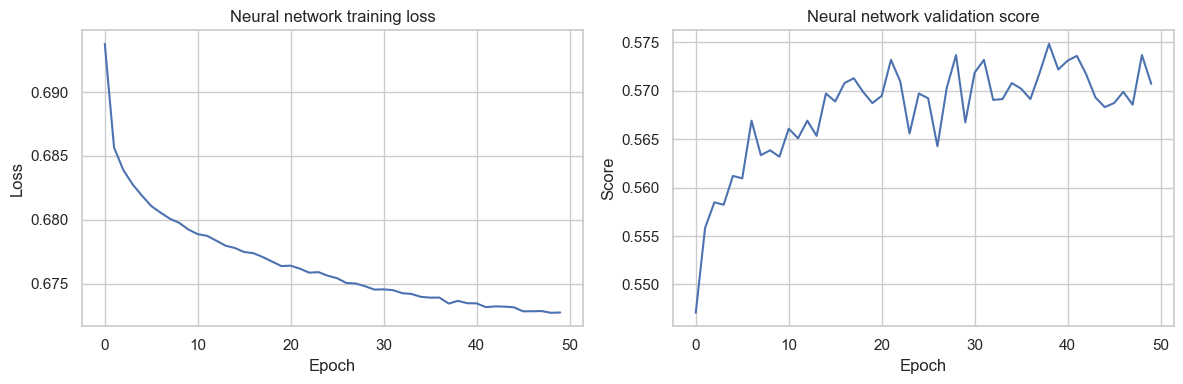

In [8]:
mlp_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", MLPClassifier(
        max_iter=80,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=SEED,
    )),
])

mlp_grid = {
    "classifier__hidden_layer_sizes": [(32,), (64, 32)],
    "classifier__alpha": [0.0001, 0.001],
    "classifier__learning_rate_init": [0.001, 0.003],
}

mlp_search = GridSearchCV(
    estimator=mlp_pipe,
    param_grid=mlp_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    verbose=0,
)

mlp_search.fit(X_train_tuning, y_train_tuning)

best_mlp = clone(mlp_search.best_estimator_)
best_mlp.fit(X_train, y_train)
best_models["Neural Network"] = best_mlp

mlp_validation_metrics = evaluate_classifier(best_mlp, X_validation, y_validation)
mlp_threshold, mlp_threshold_table = select_threshold_on_validation(best_mlp, X_validation, y_validation, validation_df)
threshold_tables["Neural Network"] = mlp_threshold_table

mlp_row = {
    "model": "Neural Network",
    "best_cv_roc_auc": mlp_search.best_score_,
    "validation_threshold": mlp_threshold,
    **mlp_validation_metrics,
    "best_params": mlp_search.best_params_,
}

print("Best CV ROC AUC:", round(mlp_search.best_score_, 4))
print("Best params:", mlp_search.best_params_)
print("Validation ROC AUC:", round(mlp_validation_metrics["roc_auc"], 4))
print("Selected threshold:", round(mlp_threshold, 2))

mlp_classifier = best_mlp.named_steps["classifier"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(mlp_classifier.loss_curve_)
ax[0].set_title("Neural network training loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")

if hasattr(mlp_classifier, "validation_scores_"):
    ax[1].plot(mlp_classifier.validation_scores_)
    ax[1].set_title("Neural network validation score")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Score")
else:
    ax[1].axis("off")

plt.tight_layout()
plt.show()

### Interpretation of the neural network results

The neural network is competitive but does not clearly dominate the simpler models. This is important because neural networks can easily overfit noisy financial data. The loss curve and validation-score curve help us check whether training is stable. In this project, the neural network is useful to satisfy the assignment requirement and to test non-linear interactions, but it is not automatically preferred over Random Forest or Logistic Regression.

## Model evaluation

Model selection is based on validation ROC AUC, because ROC AUC evaluates the quality of the probability ranking before choosing a trading threshold. The trading threshold is selected on the validation period by maximizing validation Sharpe ratio subject to minimum exposure. The final test set is used once, after choosing the model and threshold on validation data.

The trading rule is intentionally simple: long if `P(up)` is above the selected threshold, no position otherwise. Transaction costs are included as a conservative penalty when positions change.

In [9]:
all_validation_results = pd.concat([
    classical_results_df,
    pd.DataFrame([mlp_row]),
], ignore_index=True).sort_values("roc_auc", ascending=False).reset_index(drop=True)

print("Validation comparison:")
display(all_validation_results.drop(columns="best_params"))

final_model_name = all_validation_results.iloc[0]["model"]
final_threshold = float(all_validation_results.iloc[0]["validation_threshold"])
final_model = best_models[final_model_name]

print("Final selected model:", final_model_name)
print("Final selected threshold:", round(final_threshold, 2))

Validation comparison:


,model,best_cv_roc_auc,validation_threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Random Forest,0.563817,0.52,0.550178,0.552851,0.591613,0.514834,0.550560,0.562827,0.590126
1,Logistic Regression,0.570784,0.53,0.551367,0.547363,0.577209,0.604315,0.590451,0.560868,0.578994
2,Neural Network,0.560725,0.65,0.540584,0.536605,0.567719,0.593210,0.580185,0.549584,0.573718
3,Gradient Boosting,0.554596,0.50,0.540160,0.542171,0.579381,0.513565,0.544491,0.548000,0.574198
4,KNN,0.545386,0.63,0.525981,0.528299,0.565170,0.495320,0.527945,0.539393,0.576761
5,Decision Tree,0.542227,0.64,0.519528,0.521742,0.558165,0.490243,0.522004,0.528328,0.556637


Final selected model: Random Forest
Final selected threshold: 0.52


In [10]:
def evaluate_on_test(model_name, model, threshold):
    proba = get_positive_proba(model, X_test)
    pred_050 = (proba >= 0.50).astype(int)
    pred_selected = (proba >= threshold).astype(int)
    cls_050 = classification_metrics(y_test, pred_050, proba)
    cls_selected = classification_metrics(y_test, pred_selected, proba)
    trd = trading_metrics(test_df, proba, threshold=threshold)
    return proba, pred_selected, cls_050, cls_selected, trd


test_rows = []
test_probabilities = {}
for _, row in all_validation_results.iterrows():
    model_name = row["model"]
    threshold = float(row["validation_threshold"])
    proba, pred_selected, cls_050, cls_selected, trd = evaluate_on_test(model_name, best_models[model_name], threshold)
    test_probabilities[model_name] = proba
    test_rows.append({
        "model": model_name,
        "threshold": threshold,
        "roc_auc": cls_selected["roc_auc"],
        "f1_at_threshold": cls_selected["f1"],
        "precision_at_threshold": cls_selected["precision"],
        "recall_at_threshold": cls_selected["recall"],
        **trd,
    })

test_results_df = pd.DataFrame(test_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
print("Test results for all tuned models:")
display(test_results_df)

final_proba = test_probabilities[final_model_name]
final_pred = (final_proba >= final_threshold).astype(int)

print("Classification report for final model on test set:")
print(classification_report(y_test, final_pred, zero_division=0))
print("Confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_test, final_pred), index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))

Test results for all tuned models:


,model,threshold,roc_auc,f1_at_threshold,precision_at_threshold,recall_at_threshold,cumulative_return,annualized_sharpe,max_drawdown,avg_position_rate,turnover,n_trades
0,Random Forest,0.52,0.568183,0.492235,0.567559,0.434562,0.020333,0.116064,-0.236298,0.380947,0.454775,3967
1,Neural Network,0.65,0.556116,0.150388,0.550218,0.087097,0.013135,0.188546,-0.082925,0.078757,0.130689,1140
2,Gradient Boosting,0.50,0.548079,0.530982,0.542137,0.520276,-0.017426,-0.096613,-0.306163,0.477473,0.461653,4027
3,Logistic Regression,0.53,0.547693,0.414889,0.547826,0.333871,0.093402,0.655065,-0.146789,0.303221,0.382323,3335
4,KNN,0.63,0.536424,0.127146,0.563406,0.071659,0.020079,0.546795,-0.048903,0.063281,0.116359,1015
5,Decision Tree,0.64,0.517816,0.231034,0.539307,0.147005,-0.020567,-0.249752,-0.078333,0.135618,0.230311,2009


Classification report for final model on test set:
              precision    recall  f1-score   support

           0       0.55      0.67      0.60      4383
           1       0.57      0.43      0.49      4340

    accuracy                           0.55      8723
   macro avg       0.56      0.55      0.55      8723
weighted avg       0.56      0.55      0.55      8723

Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,2946,1437
Actual 1,2454,1886


,strategy,threshold,cumulative_return,annualized_sharpe,max_drawdown,avg_position_rate,turnover,n_trades
0,ML long/no-position,0.52,0.020333,0.116064,-0.236298,0.380947,0.454775,3967
1,Equal-weight buy-and-hold,NaN,-0.087892,-0.319740,-0.454615,1.000000,0.000000,0


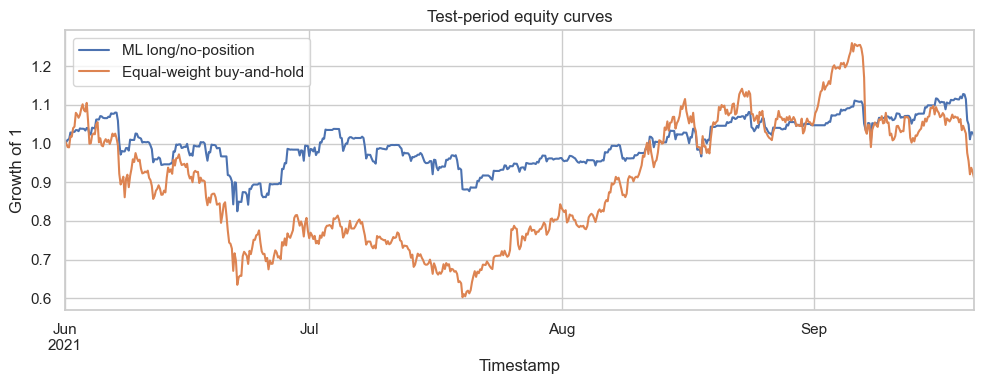

In [11]:
buy_hold = buy_and_hold_metrics(test_df)
strategy = trading_metrics(test_df, final_proba, threshold=final_threshold)

trading_comparison = pd.DataFrame([
    {"strategy": "ML long/no-position", **strategy},
    {"strategy": "Equal-weight buy-and-hold", **buy_hold},
])

display(trading_comparison)

backtest_df = test_df[["timestamp", "Asset_ID", return_col]].copy()
backtest_df["proba_up"] = final_proba
backtest_df["position"] = (backtest_df["proba_up"] >= final_threshold).astype(int)
backtest_df = backtest_df.sort_values(["Asset_ID", "timestamp"])
backtest_df["trade"] = backtest_df.groupby("Asset_ID")["position"].diff().abs().fillna(backtest_df["position"])
backtest_df["strategy_return"] = backtest_df["position"] * backtest_df[return_col] - TRANSACTION_COST * backtest_df["trade"]

strategy_period_returns = backtest_df.groupby("timestamp")["strategy_return"].mean().sort_index()
buy_hold_period_returns = test_df.groupby("timestamp")[return_col].mean().sort_index()

equity_curves = pd.DataFrame({
    "ML long/no-position": np.exp(strategy_period_returns.cumsum()),
    "Equal-weight buy-and-hold": np.exp(buy_hold_period_returns.cumsum()),
})

equity_curves.plot(figsize=(10, 4))
plt.title("Test-period equity curves")
plt.ylabel("Growth of 1")
plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

### Interpretation of the final test results

The Random Forest is selected because it has the highest validation ROC AUC. On the test period it reaches ROC AUC around 0.568 and accuracy around 55%, which is modest but above the random baseline expected for a nearly balanced target. This is realistic for short-horizon crypto direction forecasting: the problem is noisy and we should not expect very high classification accuracy.

The trading backtest is the more relevant business output. The final long/no-position strategy has positive cumulative return on the test period, while the equal-weight buy-and-hold benchmark loses money over the same period. However, the Sharpe ratio is low and the maximum drawdown is still meaningful, so the correct conclusion is not that we found a perfect trading system. The conclusion is that a simple ML probability model can produce a disciplined trading rule with some useful signal, but the edge is weak and should be treated carefully.

## Model interpretation

We use two interpretation techniques from the course. First, Logistic Regression coefficients show the direction of the linear relationship after preprocessing. Second, permutation importance measures how much the final model's ROC AUC decreases when a feature is randomly shuffled. This second method is model-agnostic and can be used for the selected trading model.

Largest absolute Logistic Regression coefficients:


,feature,coefficient,abs_coefficient
15,cat__Asset_Name_Bitcoin,0.255067,0.255067
24,cat__Asset_Name_Monero,0.248711,0.248711
26,cat__Asset_Name_TRON,-0.246629,0.246629
18,cat__Asset_Name_Dogecoin,-0.241731,0.241731
4,num__Rolling_Return_Mean_6,-0.191447,0.191447
17,cat__Asset_Name_Cardano,-0.184589,0.184589
8,num__VWAP_Deviation,-0.183772,0.183772
9,num__Log_Volume,0.150239,0.150239
11,num__Market_Return_Ex_Asset,0.145459,0.145459
3,num__Return_Lag_3,0.143489,0.143489


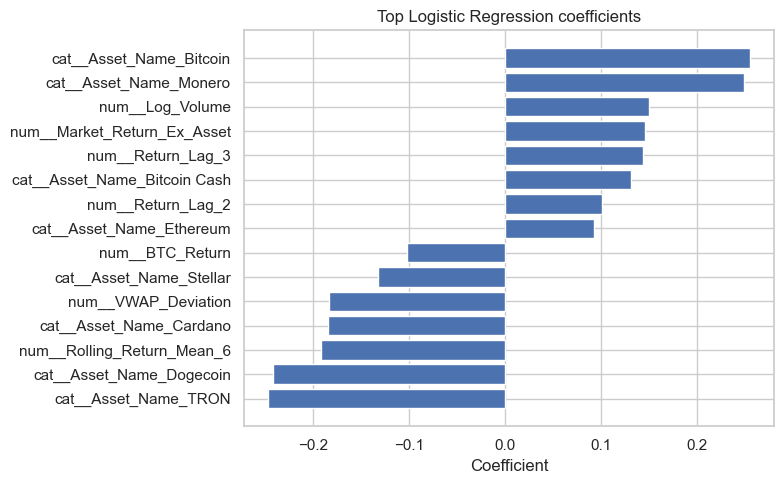

In [12]:
logistic_model = best_models["Logistic Regression"]
feature_names = logistic_model.named_steps["preprocess"].get_feature_names_out()
logistic_coef = logistic_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logistic_coef,
    "abs_coefficient": np.abs(logistic_coef),
}).sort_values("abs_coefficient", ascending=False)

print("Largest absolute Logistic Regression coefficients:")
display(coef_df.head(20))

plt.figure(figsize=(8, 5))
plot_df = coef_df.head(15).sort_values("coefficient")
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.title("Top Logistic Regression coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

Permutation importance for final model:


,feature,importance_mean,importance_std
8,VWAP_Deviation,0.009747,0.008687
0,Return_Current_4H,0.005465,0.005985
12,BTC_Return,0.005317,0.000839
13,ETH_Return,0.003811,0.001420
10,Log_Count_Change_1,0.001099,0.000593
11,Market_Return_Ex_Asset,0.000535,0.000844
9,Log_Volume,0.000471,0.000187
14,Asset_Name,0.000464,0.000358
5,Rolling_Volatility_6,0.000244,0.000467
6,Rolling_Volatility_42,0.000159,0.000146


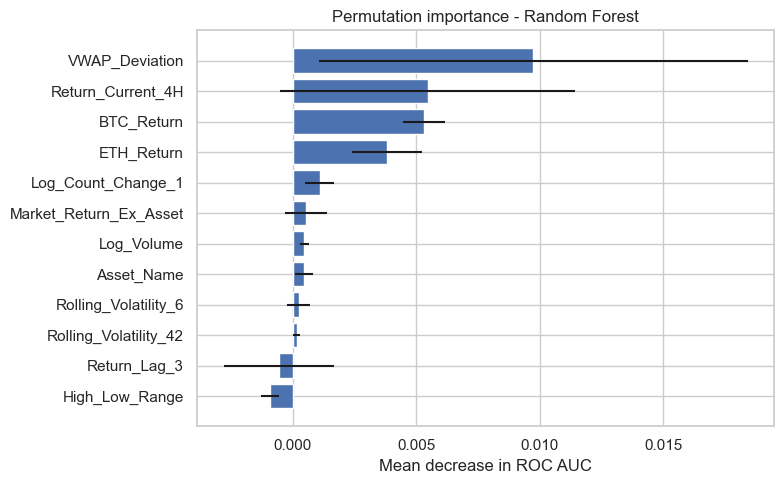

In [13]:
interpretation_size = min(1500, len(X_test))
X_interpret = X_test.sample(n=interpretation_size, random_state=SEED)
y_interpret = y_test.loc[X_interpret.index]

perm = permutation_importance(
    final_model,
    X_interpret,
    y_interpret,
    scoring="roc_auc",
    n_repeats=3,
    random_state=SEED,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

print("Permutation importance for final model:")
display(perm_df)

plt.figure(figsize=(8, 5))
plot_df = perm_df.head(12).sort_values("importance_mean")
plt.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
plt.title(f"Permutation importance - {final_model_name}")
plt.xlabel("Mean decrease in ROC AUC")
plt.tight_layout()
plt.show()

### Interpretation of the feature importance results

The interpretation results are consistent with the EDA. The most relevant signals are not raw price levels, but short-term return pressure, VWAP deviation, BTC/ETH market context, liquidity/activity and asset identity. The permutation importances are small, which is expected in noisy 4-hour financial data, but the ranking is economically plausible: recent price pressure and broad market movement contain more information than distant lags.

This also explains why the model should be evaluated as a trading rule rather than only as a classifier. Even modest probability improvements can be useful if they help the strategy avoid some bad periods, but the signal is not strong enough to justify an over-complex model.

## Conclusion

This notebook builds an assignment-ready algorithmic trading model. The EDA led us to use returns rather than prices, remove Maker because of structural gaps, keep the remaining 13 assets with gap-aware targets and features, and use a compact set of return, volatility, liquidity and market-context variables.

The final model is selected on the validation period and evaluated once on the test period. The key result is not only whether the classifier has ROC AUC above the baseline, but whether its probability forecasts can be converted into a simple trading rule that is competitive with an equal-weight buy-and-hold benchmark after transaction costs. The interpretation section then checks whether the learned signals are economically plausible instead of treating the model as a black box.